In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas_datareader import data as pdr
import datetime as dt
from scipy import stats
import yfinance as yf
import time

sns.set_style('whitegrid')
%matplotlib inline

In [ ]:
start_date_str = '2020-05-01'

start_date = dt.datetime.strptime(start_date_str, '%Y-%m-%d')

end_date = dt.datetime.today()

tickers = ['AAPL','MSFT', 'GOOGL', 'AMZN']
weights =  np.array([0.25,0.25,0.25,0.25])

prices = yf.download(tickers, start=start_date, end=end_date)['Close']

print(prices)

/tmp/ipython-input-3-2254404203.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices = yf.download(tickers, start=start_date, end=end_date)['Close']
[*********************100%***********************]  4 of 4 completed

Ticker            AAPL        AMZN       GOOGL        MSFT
Date                                                      
2020-05-01   70.059341  114.302002   65.473335  166.788513
2020-05-04   71.050613  115.799500   65.750671  170.868164
2020-05-05   72.116997  115.889999   67.048882  172.702576
2020-05-06   72.861069  117.563004   66.870461  174.403275
2020-05-07   73.614792  118.380501   68.055847  175.415985
...                ...         ...         ...         ...
2025-06-12  199.199997  213.240005  175.699997  478.869995
2025-06-13  196.449997  212.100006  174.669998  474.959991
2025-06-16  198.419998  216.100006  176.770004  479.140015
2025-06-17  195.639999  214.820007  175.949997  478.040009
2025-06-18  196.580002  212.520004  173.320007  480.239990

[1290 rows x 4 columns]


In [ ]:
prices.head()

Ticker,AAPL,AMZN,GOOGL,MSFT
Date,,,,
2020-05-01,70.059341,114.302002,65.473335,166.788513
2020-05-04,71.050613,115.799500,65.750671,170.868164
2020-05-05,72.116997,115.889999,67.048882,172.702576
2020-05-06,72.861069,117.563004,66.870461,174.403275
2020-05-07,73.614792,118.380501,68.055847,175.415985


In [ ]:
prices.isnull().sum()

,0
Ticker,
AAPL,0
AMZN,0
GOOGL,0
MSFT,0


In [ ]:
prices =  prices.dropna(how='all').ffill().bfill()

prices.head()

Ticker,AAPL,AMZN,GOOGL,MSFT
Date,,,,
2020-05-01,70.059341,114.302002,65.473335,166.788513
2020-05-04,71.050613,115.799500,65.750671,170.868164
2020-05-05,72.116997,115.889999,67.048882,172.702576
2020-05-06,72.861069,117.563004,66.870461,174.403275
2020-05-07,73.614792,118.380501,68.055847,175.415985


In [ ]:
logR = np.log(prices / prices.shift(1)).dropna()
logR.head()

Ticker,AAPL,AMZN,GOOGL,MSFT
Date,,,,
2020-05-04,0.014050,0.013016,0.004227,0.024166
2020-05-05,0.014897,0.000781,0.019552,0.010679
2020-05-06,0.010265,0.014333,-0.002665,0.009799
2020-05-07,0.010292,0.006930,0.017571,0.005790
2020-05-08,0.023523,0.005056,0.010938,0.005865


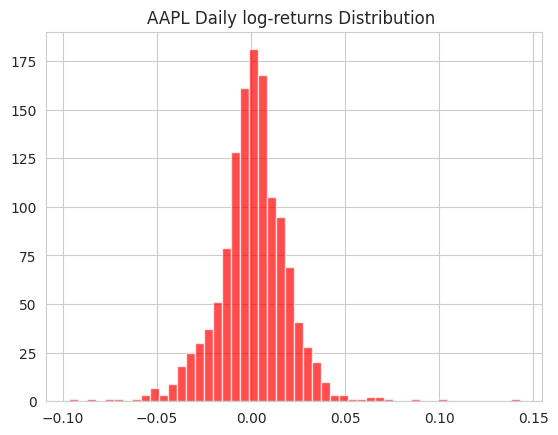

In [ ]:
ogR['AAPL'].hist(bins=50, alpha=0.7 , color='red')
plt.title('AAPL Daily log-returns Distribution ')
plt.show()

In [ ]:
summary = pd.DataFrame({
    'Mean': logR.mean(),
    'Variance': logR.var(),
    'Skewness': logR.skew(),
    'Kurtosis': logR.kurtosis(),
    'Meadian' : logR.median(),
    'std': logR.std()
})
summary

,Mean,Variance,Skewness,Kurtosis,Meadian,std
Ticker,,,,,,
AAPL,0.000800,0.000351,0.169936,4.878826,0.001233,0.018723
AMZN,0.000481,0.000497,-0.066720,4.650462,0.000554,0.022291
GOOGL,0.000755,0.000379,-0.169343,2.968727,0.001421,0.019470
MSFT,0.000820,0.000287,-0.021913,2.610610,0.001114,0.016937


/tmp/ipython-input-10-2110324655.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=summary.index, y=summary['Mean'], ax=axs[0, 0], palette='Blues_d')
/tmp/ipython-input-10-2110324655.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=summary.index, y=summary['Variance'], ax=axs[0, 1], palette='Oranges_d')
/tmp/ipython-input-10-2110324655.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=summary.index, y=summary['Skewness'], ax=axs[1, 0], palette='Greens_d')
/tmp/ipython-input-10-2110324655.py:19: FutureWarning: 

Passing `palett

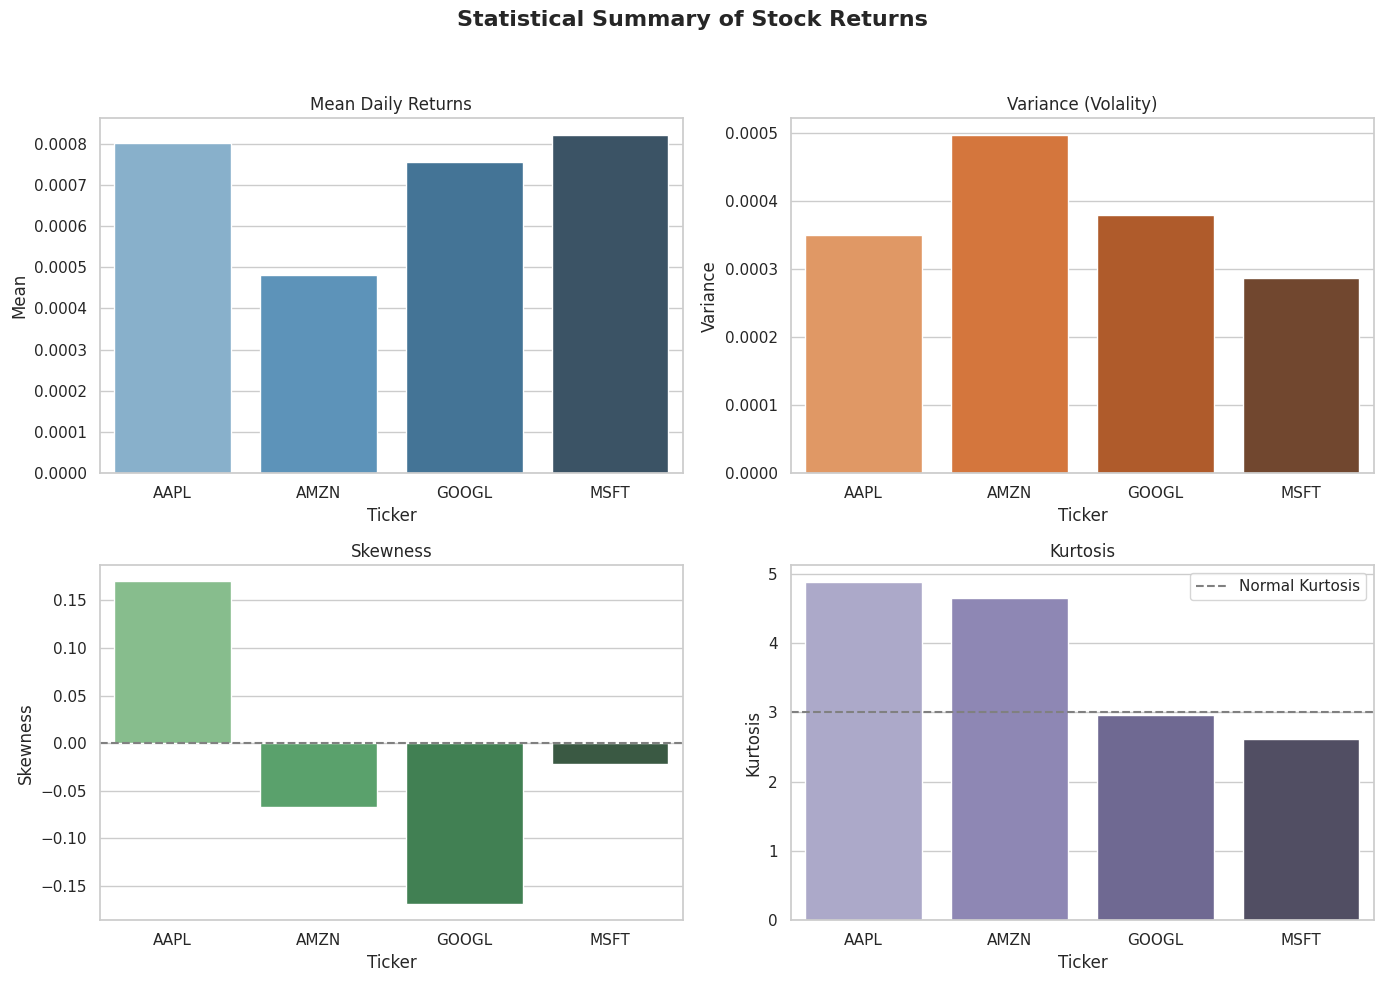

In [ ]:
sns.set(style='whitegrid')
fig, axs = plt.subplots(2, 2, figsize=(14,10))
fig.suptitle('Statistical Summary of Stock Returns', fontsize=16, fontweight='bold')

#Mean
sns.barplot(x=summary.index, y=summary['Mean'], ax=axs[0, 0], palette='Blues_d')
axs[0, 0].set_title('Mean Daily Returns')

#Variance
sns.barplot(x=summary.index, y=summary['Variance'], ax=axs[0, 1], palette='Oranges_d')
axs[0, 1].set_title('Variance (Volality)')

#Skewness
sns.barplot(x=summary.index, y=summary['Skewness'], ax=axs[1, 0], palette='Greens_d')
axs[1, 0].axhline(0, color='gray', linestyle='--')
axs[1, 0].set_title('Skewness')

#Kurtosis
sns.barplot(x=summary.index, y=summary['Kurtosis'], ax=axs[1, 1], palette='Purples_d')
axs[1, 1].axhline(3, color='gray', linestyle='--', label='Normal Kurtosis')
axs[1, 1].legend()
axs[1, 1].set_title('Kurtosis')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
mu_norm, sigma_norm = logR.stack().mean(), logR.stack().std(ddof=1)

N = logR.size
z95 = stats.norm.ppf(0.975)
ci_mu_norm = (mu_norm - z95*sigma_norm/np.sqrt(N),
              mu_norm + z95*sigma_norm/np.sqrt(N))

df = N-1
chi2_low, chi2_high = stats.chi2.ppf([0.25,0.975], df)
ci_sigma_norm = (sigma_norm*np.sqrt(df/chi2_high),
                 sigma_norm*np.sqrt(df/chi2_low))

print("Norma fit:")
print(f" μ = {mu_norm:.5f}, 95% CI {ci_mu_norm}")
print(f" σ = {sigma_norm:.5f}, 95% CI {ci_sigma_norm}")

Norma fit:
 μ = 0.00071, 95% CI (np.float64(0.00018351727393021435), np.float64(0.001245099837145183))
 σ = 0.01945, 95% CI (np.float64(0.0190778884204553), np.float64(0.019577249826255697))


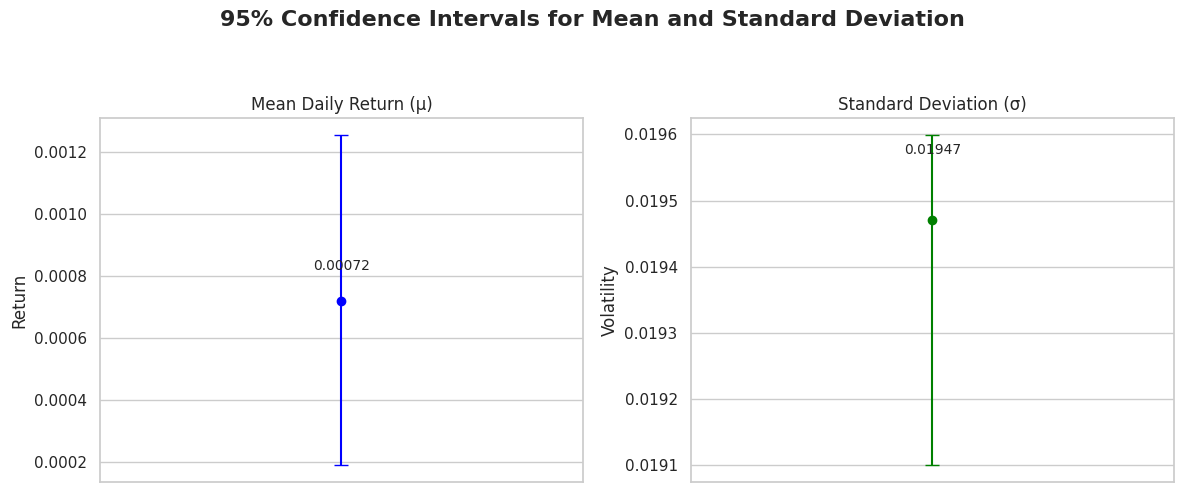

In [ ]:
mu_norm = 0.00072
ci_mu_norm = (0.00018965025974952948, 0.001254076767595418)

sigma_norm = 0.01947
ci_sigma_norm = (0.019098731631288498, 0.019599423114504286)

fig, axs = plt.subplots(1, 2, figsize=(12,5))
fig.suptitle('95% Confidence Intervals for Mean and Standard Deviation', fontsize=16, fontweight='bold')

#plot for mean
axs[0].errorbar(x=0, y=mu_norm,
                yerr=[[mu_norm - ci_mu_norm[0]], [ci_mu_norm[1] - mu_norm]],
                fmt='o', color='blue', capsize=5)
axs[0].set_title('Mean Daily Return (μ)')
axs[0].set_ylabel('Return')
axs[0].set_xticks([])
axs[0].grid(True)
axs[0].text(0, mu_norm + 0.0001, f'{mu_norm:.5f}', ha='center', fontsize=10)

#Plot for Standard deviation
axs[1].errorbar(x=0, y=sigma_norm,
                yerr=[[sigma_norm - ci_sigma_norm[0]], [ci_sigma_norm[1] - sigma_norm]],
                fmt='o', color='green', capsize=5)

axs[1].set_title('Standard Deviation (σ)')
axs[1].set_ylabel('Volatility')
axs[1].set_xticks([])
axs[1].grid(True)
axs[1].text(0, sigma_norm + 0.0001, f'{sigma_norm:.5f}', ha='center', fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

In [ ]:
returns_flat = logR.stack().values

df_t, mu_t, sigma_t = stats.t.fit(returns_flat)

print(df_t)
print(mu_t)
print(sigma_t)

4.212895186252595
0.0010475664827167119
0.014277047918265158


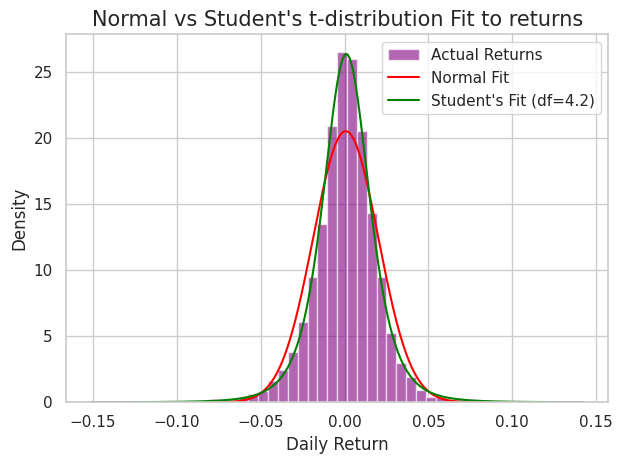

In [ ]:
returns_flat = logR.stack().values

mu_norm, sigma_norm = returns_flat.mean(), returns_flat.std(ddof=1)

df_t, mu_t, sigma_t = stats.t.fit(returns_flat)

x =  np.linspace(returns_flat.min(), returns_flat.max(), 1000)
hist_vals, bins, t = plt.hist(returns_flat, bins=50, density=True, alpha=0.6, color='purple', label='Actual Returns')

#Normal pdf
plt.plot(x, stats.norm.pdf(x, mu_norm, sigma_norm), label='Normal Fit', color='red')

#students t pdf
plt.plot(x, stats.t.pdf(x, df_t, mu_t, sigma_t), label=f"Student's Fit (df={df_t:.1f})", color='green')

plt.title("Normal vs Student\'s t-distribution Fit to returns", fontsize=15)
plt.xlabel('Daily Return')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
B = 100
estimates =  np.array([stats.t.fit(np.random.choice(returns_flat, size=N, replace=True))
                       for _ in range(B)])

ci_mu_t = np.percentile(estimates[:,1], [2.5,97.5])
ci_sigma_t = np.percentile(estimates[:,2], [2.5,97.5])

print("\nStudent's fit:")
print(f" df = {df_t:.1f}, μ = {mu_t:.5f}, σ = {sigma_t:.5f}")
print(f" 95% CI for μ (bootstrap): {ci_mu_t}")
print(f" 95% CI for σ (bootstrap): {ci_sigma_t}")


Student's fit:
 df = 4.2, μ = 0.00105, σ = 0.01428
 95% CI for μ (bootstrap): [0.00063438 0.00152372]
 95% CI for σ (bootstrap): [0.01387101 0.01469792]


In [ ]:
portR = logR.dot(weights)

μ_p = portR.mean()
σ_p = portR.std(ddof=1)

z05 =  stats.norm.ppf(0.05)
VaR_norm = - (μ_p + σ_p * z05)
print(VaR_norm)

0.026571414774884266


In [ ]:
t05 =  stats.t.ppf(0.05, df_t)
VaR_t = - (mu_t + sigma_t * t05) * 1
print(VaR_t)

0.028952320900192452


In [ ]:
hist_var = -np.percentile(portR, 5)

print("1-Day 95% VaR:")
print(f" Parametric (Normal):  {VaR_norm:.5f}")
print(f" Parametric(Student's t):  {VaR_t:.5f}")
print(f" Historical (5th perentile):  {hist_var:.5f}")

1-Day 95% VaR:
 Parametric (Normal):  0.02657
 Parametric(Student's t):  0.02895
 Historical (5th perentile):  0.02714


In [ ]:
t_stat, p_val = stats.ttest_1samp(portR, 0.0)
print("One-sample t-test on potfolio daily returns: ")
print(f" t-statistic = {t_stat:.3f}, p-value = {p_val:.3f}")

if p_val < 0.05:
  print(" -> Reject H0: mean return is significantly different from zero.")
else:
  print(" -> Fail to reject H0: no evidence mean return is not equal to 0.")

One-sample t-test on potfolio daily returns: 
 t-statistic = 1.546, p-value = 0.122
 -> Fail to reject H0: no evidence mean return is not equal to 0.


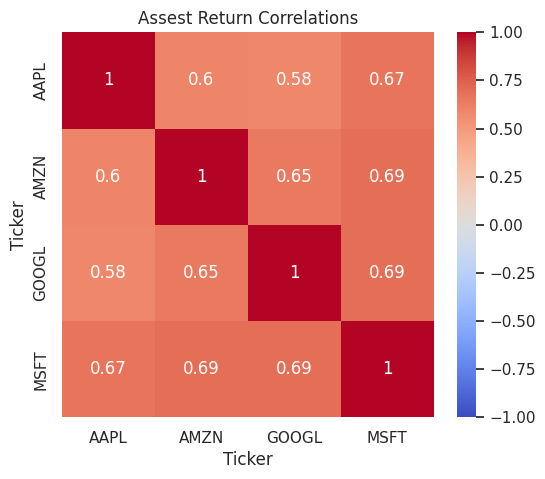

Weighted avg σ : 0.0194
Actual portfolio σ : 0.0166
Diversification Benifit: 0.0028


In [ ]:
#correlation and diversification denifit

# a) Correlation heatmap
corr = logR.corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Assest Return Correlations')
plt.show()

# b) Diversification benifit
σ_i = logR.std()                       # individual volatilities
σ_weighted = np.dot(weights, σ_i)      # naive weighted avfg
σ_portfolio = σ_p                      # from earlier
print(f"Weighted avg σ : {σ_weighted:.4f}")
print(f"Actual portfolio σ : {σ_portfolio:.4f}")
print(f"Diversification Benifit: {σ_weighted-σ_portfolio:.4f}")

Max Drawdown : -43.98%
From 2021-12-10 to 2023-01-05


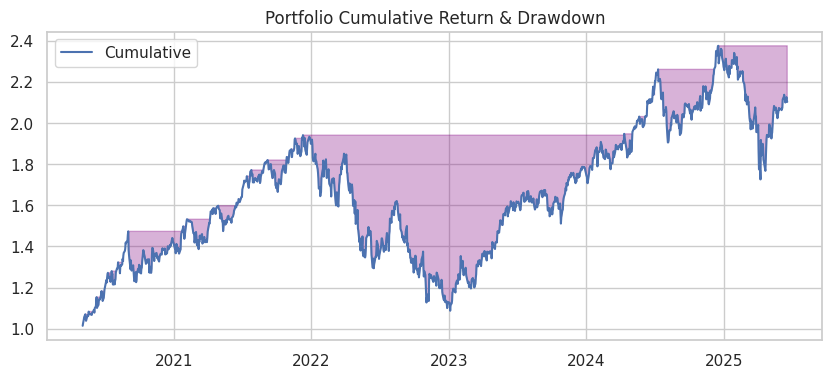

In [ ]:
#max dropdown
cum_ret = (prices / prices.iloc[0]).prod(axis=1)

# Actually for portfolio: cum_port = (portR + 1).cumprod()
cum_port = (portR +  1).cumprod()

rolling_max = cum_port.cummax()
drawdown = (cum_port - rolling_max) / rolling_max

max_dd = drawdown.min()
end_date = drawdown.idxmin()
start_date = cum_port[:end_date].idxmax()

print(f"Max Drawdown : {max_dd:.2%}")
print(f"From {start_date.date()} to {end_date.date()}")

#Plot
plt.figure(figsize=(10,4))
plt.plot(cum_port, label='Cumulative')
plt.fill_between(drawdown.index, cum_port, rolling_max,
                 where=drawdown<0, color='purple', alpha=0.3)
plt.title('Portfolio Cumulative Return & Drawdown')
plt.legend()
plt.show()

In [ ]:
 # Expected shortfall (CVaR at 95%)
 alpha = 0.05
 # Historical ES
 es_hist= - portR[portR <= np.percentile(portR, 5)].mean()
 # Parametric ES under normal
 es_norm = - (μ_p - σ_p * stats.norm.pdf(z05) / alpha)

 print(f"Historical ES (95%): {es_hist:.5f}")
 print(f"Parametric Normal ES (95%): {es_norm:.5f}")

Historical ES (95%): 0.03798
Parametric Normal ES (95%): 0.03350


In [ ]:
# VaR Backtesting
exceptions = portR < -VaR_norm
num_exc = exceptions.sum()
total = len(portR)
print(f"Exceptions : {num_exc}/{total} days ({num_exc/total:.2f}, expected -5%)")

Exceptions : 70/1289 days (0.05, expected -5%)


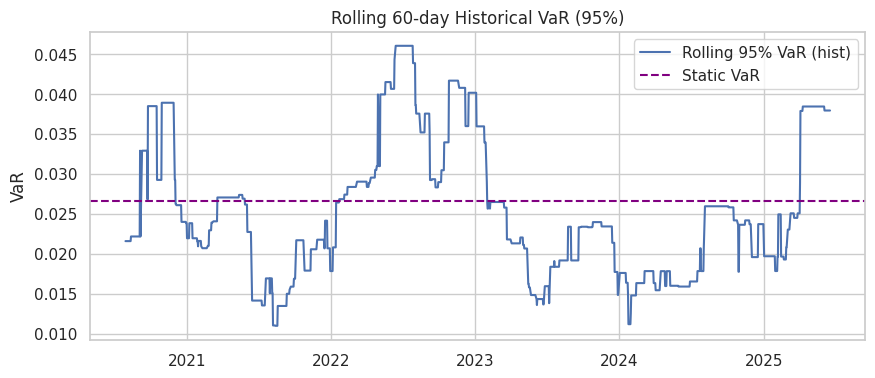

In [ ]:
# Rolling 60-days VaR
window = 60
roll_var = portR.rolling(window).quantile(0.05).dropna()
plt.figure(figsize=(10,4))
plt.plot(-roll_var, label='Rolling 95% VaR (hist)')
plt.axhline(VaR_norm, color = 'Purple', linestyle='--', label='Static VaR')
plt.title('Rolling 60-day Historical VaR (95%)')
plt.ylabel('VaR')
plt.legend()
plt.show()

In [ ]:
# Jarque-Bera Normality Test
jb_stat, jb_p = stats.jarque_bera(portR)
print(f"JB statistic = {jb_stat:.2f}, p-value = {jb_p:.3f}")
if jb_p < 0.05:
  print("Reject normality at 5% level.")
else:
  print("Cannot Reject Normality")

JB statistic = 472.77, p-value = 0.000
Reject normality at 5% level.
